In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ====== 数据 ======
data = [
    # Rollout n=1
    {'Group': 'rolloutn=1', 'Method': 'PPO', 'Score': 5.104},
    {'Group': 'rolloutn=1', 'Method': 'IQN(0)', 'Score': 4.479},
    {'Group': 'rolloutn=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    # Rollout n=2
    {'Group': 'rolloutn=2', 'Method': 'IQN(0)', 'Score': 6.285},
    {'Group': 'rolloutn=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    # Rollout n=8
    {'Group': 'rolloutn=8', 'Method': 'GRPO', 'Score': 6.563},
    {'Group': 'rolloutn=8', 'Method': 'IQN(0)', 'Score': 7.535},
    {'Group': 'rolloutn=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]

df = pd.DataFrame(data)
method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
group_order = ['rolloutn=1', 'rolloutn=2', 'rolloutn=8']

# 颜色：强调 IQN(SR) 的优势
palette = {
    'PPO': '#9aa0a6',
    'GRPO': '#e76f51',
    'IQN(0)': '#4c78a8',
    'IQN(SR)': '#2a9d8f',
}


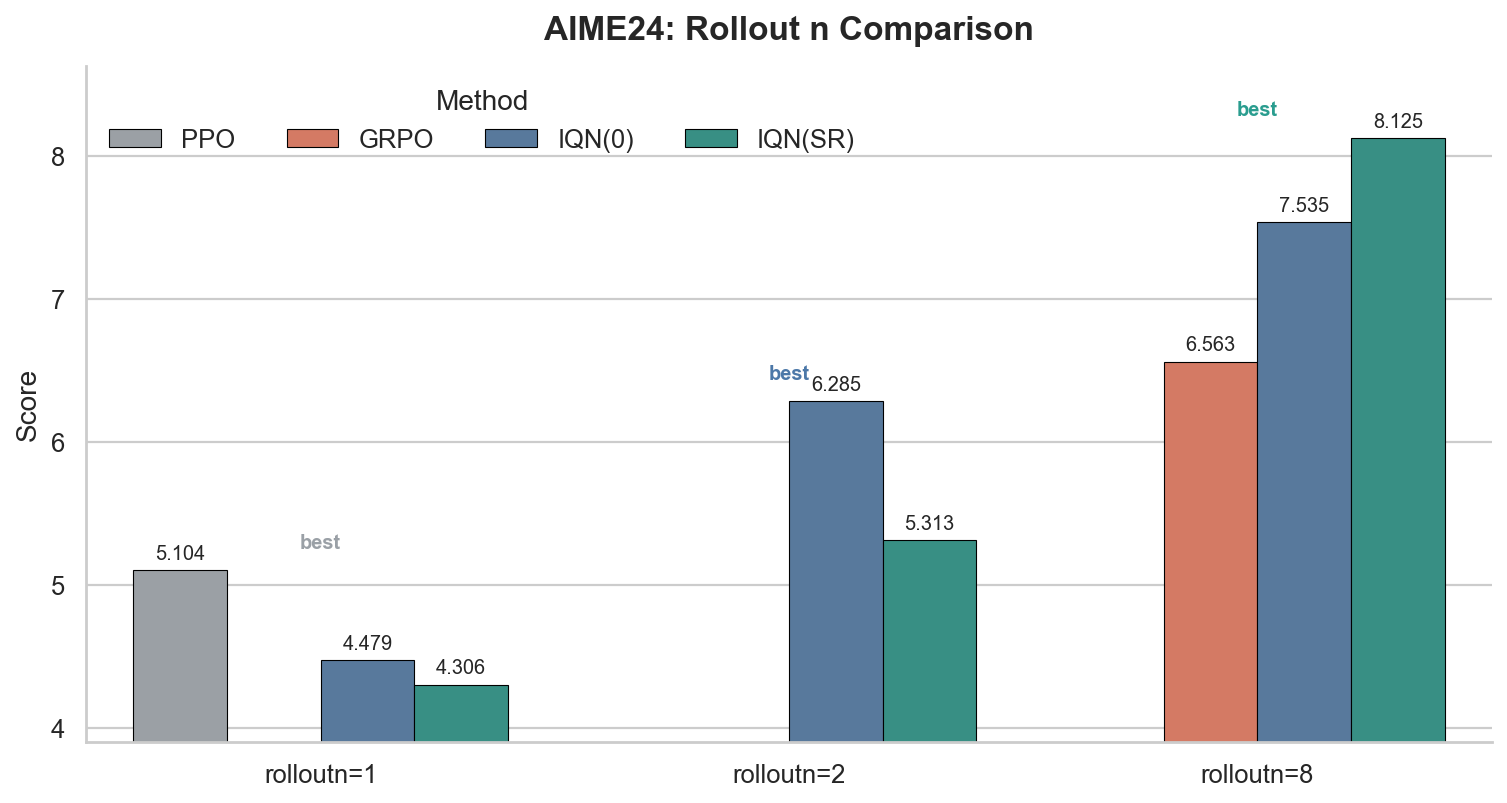

In [19]:
# ====== 风格 A：高级分组柱 + 优势标注 ======
sns.set_theme(style='whitegrid', font_scale=1.05)
fig, ax = plt.subplots(figsize=(9.6, 5.2), dpi=160)

bar = sns.barplot(
    data=df,
    x='Group',
    y='Score',
    hue='Method',
    order=group_order,
    hue_order=[m for m in method_order if m in df['Method'].unique()],
    palette=palette,
    edgecolor='black',
    linewidth=0.5,
)

# 数值标注 + 强调最高值
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

# y 轴不从 0 开始，更聚焦差异
ymin = df['Score'].min() - 0.4
ymax = df['Score'].max() + 0.5
ax.set_ylim(ymin, ymax)

ax.set_title('AIME24: Rollout n Comparison', fontsize=15, pad=12, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(title='Method', ncol=4, frameon=False, loc='upper left')

# 在每个 group 标出最好表现
for g in group_order:
    sub = df[df['Group'] == g]
    best = sub.loc[sub['Score'].idxmax()]
    ax.annotate(
        'best',
        xy=(g, best['Score']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color=palette[best['Method']],
    )

sns.despine()
plt.tight_layout()
plt.show()


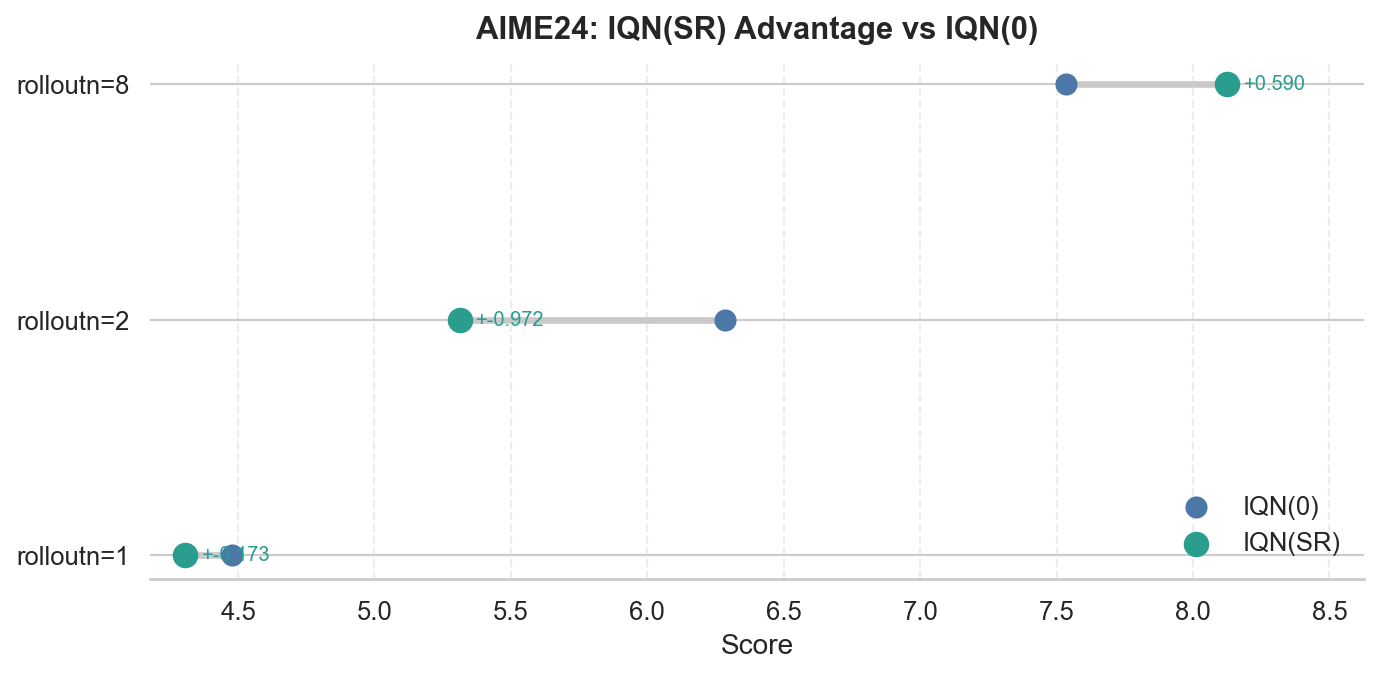

In [20]:
# ====== 风格 B：Dumbbell 对比 (IQN(0) vs IQN(SR)) ======
fig, ax = plt.subplots(figsize=(8.8, 4.4), dpi=160)

# 仅对 IQN(0) 与 IQN(SR) 进行成对对比
pairs = []
for g in group_order:
    sub = df[df['Group'] == g].set_index('Method')
    if 'IQN(0)' in sub.index and 'IQN(SR)' in sub.index:
        pairs.append((g, sub.loc['IQN(0)', 'Score'], sub.loc['IQN(SR)', 'Score']))

ypos = np.arange(len(pairs))
for i, (g, v0, vsr) in enumerate(pairs):
    ax.plot([v0, vsr], [i, i], color='#c9c9c9', lw=3, zorder=1)
    ax.scatter(v0, i, s=80, color=palette['IQN(0)'], label='IQN(0)' if i == 0 else None, zorder=2)
    ax.scatter(vsr, i, s=110, color=palette['IQN(SR)'], label='IQN(SR)' if i == 0 else None, zorder=3)
    ax.text(vsr + 0.06, i, '+{:.3f}'.format(vsr - v0), va='center', fontsize=9, color=palette['IQN(SR)'])

ax.set_yticks(ypos)
ax.set_yticklabels([p[0] for p in pairs])
ax.set_xlabel('Score')
ax.set_title('AIME24: IQN(SR) Advantage vs IQN(0)', fontsize=14, pad=10, weight='bold')

xmin = min(v0 for _, v0, _ in pairs) - 0.3
xmax = max(v for _, _, v in pairs) + 0.5
ax.set_xlim(xmin, xmax)
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.legend(frameon=False, loc='lower right')
sns.despine(left=True)
plt.tight_layout()
plt.show()


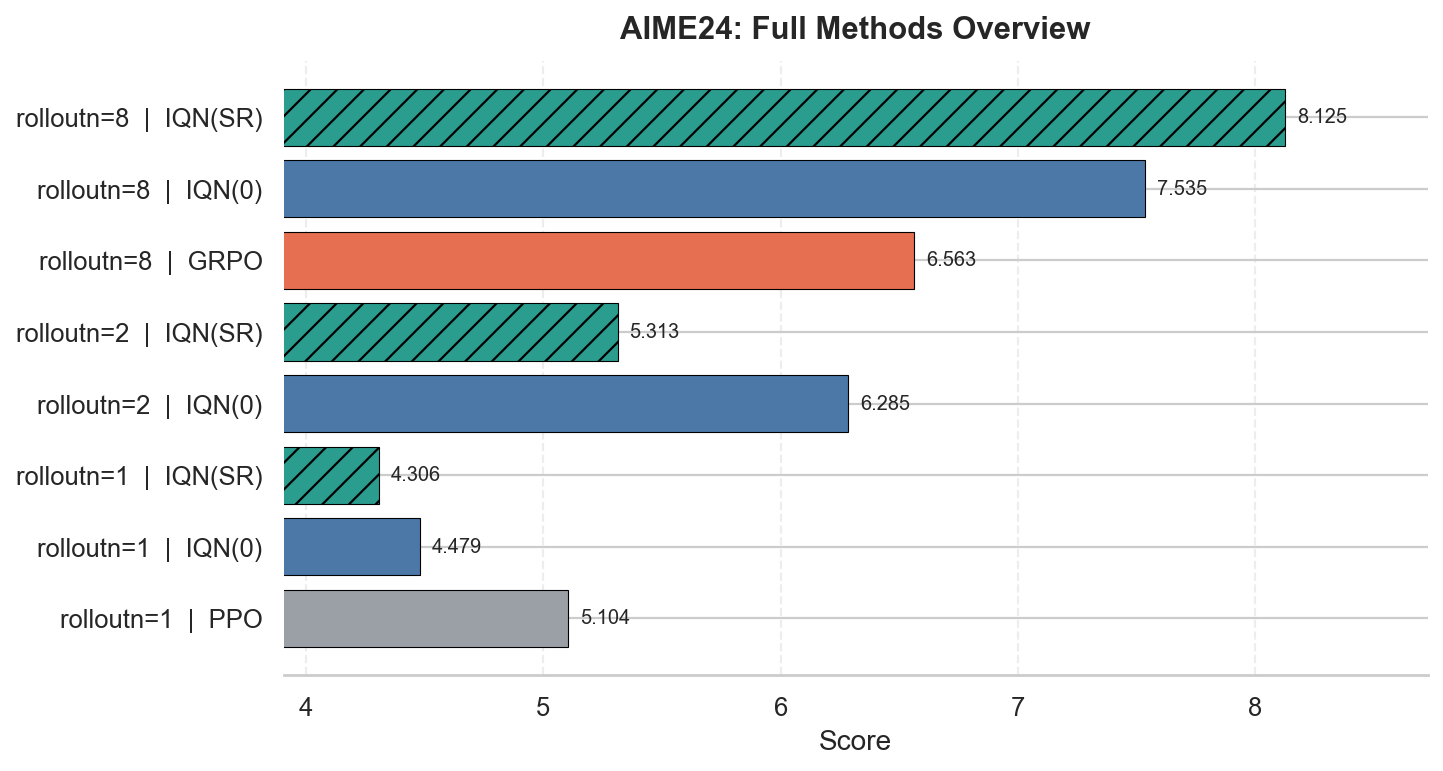

In [ ]:
# ====== 风格 C：横向条形 + 强调最佳方法 ======
fig, ax = plt.subplots(figsize=(9.2, 5.0), dpi=160)

# 让每个 group 形成一块，横向布局更易对比
plot_df = df.copy()
plot_df['Group'] = pd.Categorical(plot_df['Group'], categories=group_order, ordered=True)
plot_df['Method'] = pd.Categorical(plot_df['Method'], categories=method_order, ordered=True)
plot_df = plot_df.sort_values(['Group', 'Method'])

# 给 IQN(SR) 加 hatch 作为视觉强调
bars = ax.barh(
    y=np.arange(len(plot_df)),
    width=plot_df['Score'],
    color=[palette[m] for m in plot_df['Method']],
    edgecolor='black',
    linewidth=0.5,
)

for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
    if method == 'IQN(SR)':
        bars[i].set_hatch('//')
    ax.text(score + 0.05, i, '{:.3f}'.format(score), va='center', fontsize=9)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(['{}  |  {}'.format(g, m) for g, m in zip(plot_df['Group'], plot_df['Method'])])
ax.set_xlabel('Score')
ax.set_title('AIME24: Full Methods Overview', fontsize=14, pad=10, weight='bold')

xmin = df['Score'].min() - 0.4
xmax = df['Score'].max() + 0.6
ax.set_xlim(xmin, xmax)
ax.grid(axis='x', linestyle='--', alpha=0.35)
sns.despine(left=True)
plt.tight_layout()
plt.show()


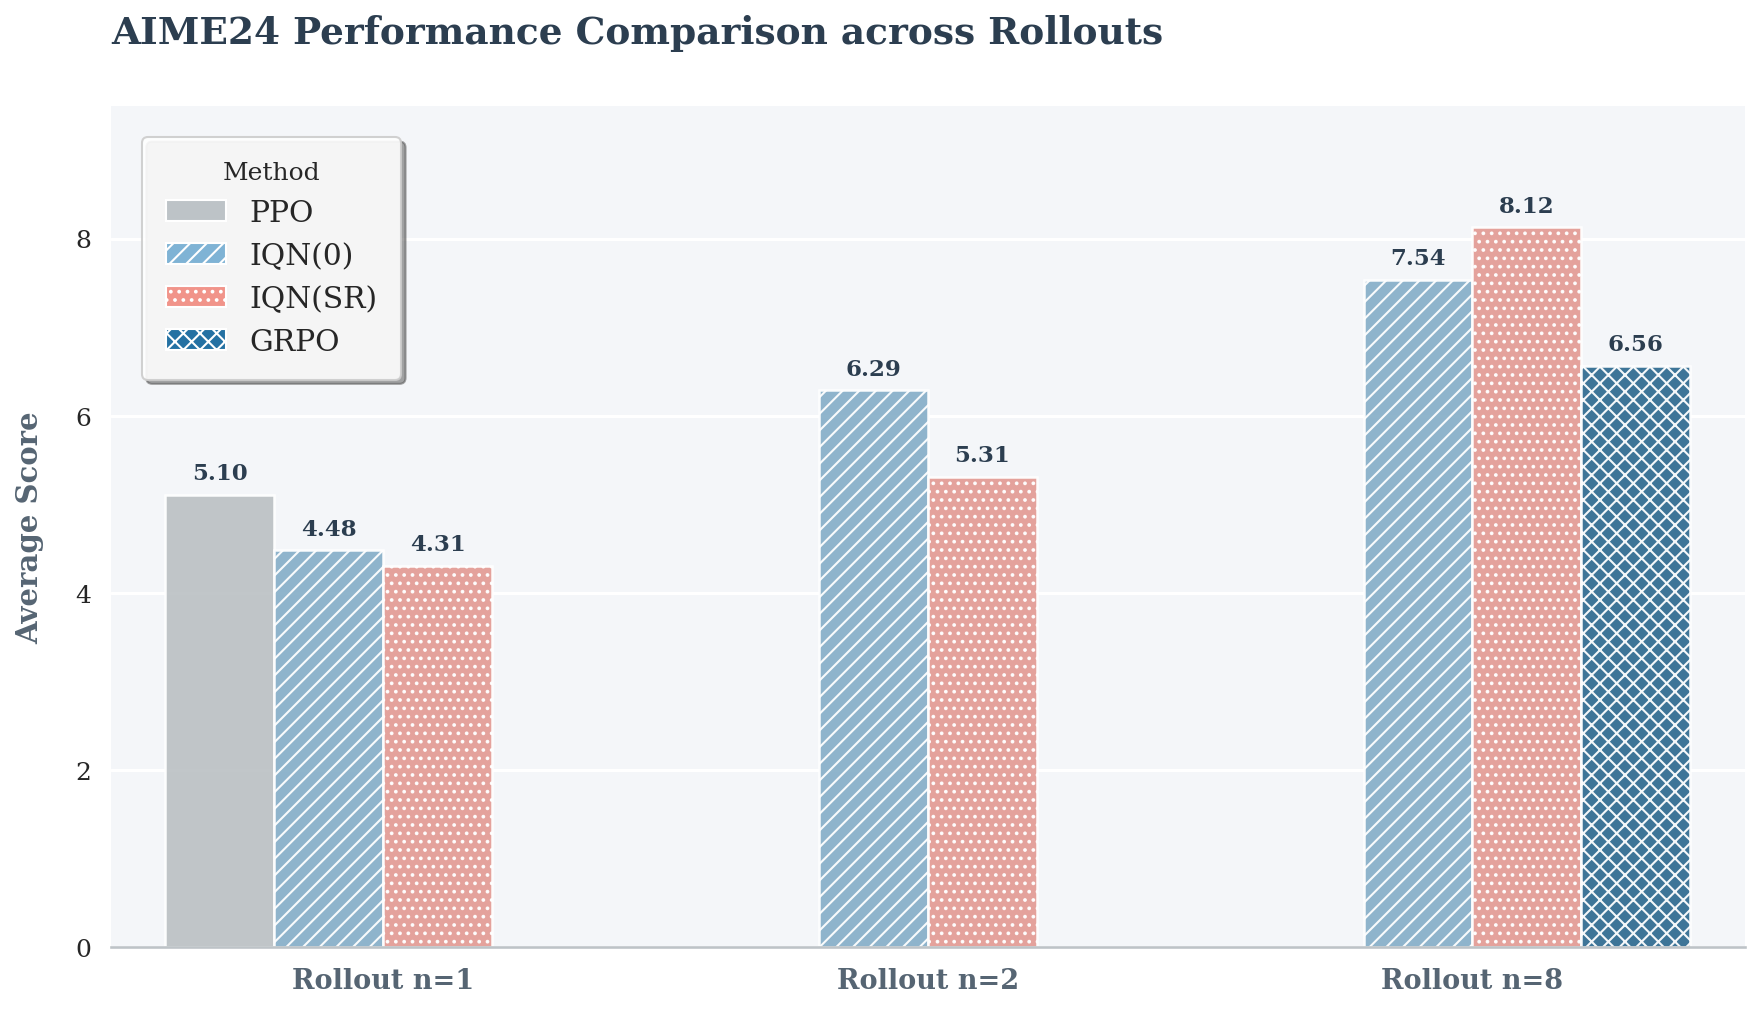

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches

# 1. 准备数据 (保持不变)
data = [
    {'Group': 'Rollout n=1', 'Method': 'PPO', 'Score': 5.104},
    {'Group': 'Rollout n=1', 'Method': 'IQN(0)', 'Score': 4.479},
    {'Group': 'Rollout n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'Rollout n=2', 'Method': 'IQN(0)', 'Score': 6.285},
    {'Group': 'Rollout n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'Rollout n=8', 'Method': 'GRPO', 'Score': 6.563},
    {'Group': 'Rollout n=8', 'Method': 'IQN(0)', 'Score': 7.535},
    {'Group': 'Rollout n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)
# 确保Method的顺序是我们想要的，方便分配颜色和纹理
method_order = ['PPO', 'IQN(0)', 'IQN(SR)', 'GRPO']
df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)


# 2. 设置绘图风格 (模仿参考图的学术感)
# 使用带微弱背景色的主题，并启用衬线字体(Serif)
sns.set_theme(style="white", font_scale=1.3)
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['axes.facecolor'] = '#f4f6f9' # 极淡的蓝灰色背景，类似参考图3
plt.rcParams['grid.color'] = 'white' # 白色网格线
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 1.5


# 3. 定义高级配色和纹理
# 配色参考了学术图表中常用的柔和对比色
# PPO(灰色基准), IQN0(柔和蓝), IQNSr(柔和橙/珊瑚), GRPO(深青色强调)
custom_palette = ['#bdc3c7', '#7fb3d5', '#f1948a', '#2471a3']

# 关键改进：定义纹理图案 (参考了图1和图4)
# ''=纯色, '/'=斜线, '.'=点状, 'x'=交叉线
hatch_patterns = ['', '///', '...', 'xxx']

# 4. 创建画布
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.set_axisbelow(True) # 确保网格线在柱子后面
ax.yaxis.grid(True)    # 只显示横向网格

# 5. 绘制柱状图基础
bar_plot = sns.barplot(
    data=df,
    x='Group',
    y='Score',
    hue='Method',
    palette=custom_palette,
    edgecolor='white', # 柱子边缘用白色，显得更干净
    linewidth=1.2,
    alpha=0.95         # 稍微一点透明度
)

# 6. 【核心步骤】为柱子添加纹理
# Seaborn原生不支持直接映射纹理，需要手动迭代添加
# 获取图例标签的顺序，确保纹理对应正确
legend_labels = [text.get_text() for text in ax.get_legend().get_texts()]

# 迭代每个hue分组的容器(container)
for i, container in enumerate(ax.containers):
    # 找到当前容器对应的Method名称
    method_name = legend_labels[i]
    # 找到该Method在我们预设顺序中的索引，从而获取对应的纹理
    pattern_idx = method_order.index(method_name)
    pattern = hatch_patterns[pattern_idx]
    
    # 为该组中的每个柱子应用纹理
    for bar in container:
        bar.set_hatch(pattern)

# 7. 美化细节

# 添加数值标签 (字体加粗，颜色深灰)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=11, fontweight='bold', color='#2c3e50')

# 标题和轴标签 (左对齐标题，更现代)
plt.title('AIME24 Performance Comparison across Rollouts', fontsize=18, fontweight='bold', pad=30, loc='left', color='#2c3e50')
plt.ylabel('Average Score', fontsize=14, labelpad=15, fontweight='bold', color='#566573')
plt.xlabel('', fontsize=14) #不需要X轴标签

# 调整Y轴范围和刻度字体
plt.ylim(0, 9.5)
plt.yticks(fontsize=12)
plt.xticks(fontsize=13, fontweight='bold', color='#566573')

# 自定义图例 (因为手动添加了纹理，图例也需要手动重建以显示纹理)
legend_handles = []
for i, method in enumerate(method_order):
    # 创建带有颜色和对应纹理的图例方块
    handle = mpatches.Patch(facecolor=custom_palette[i], hatch=hatch_patterns[i], label=method, edgecolor='white')
    legend_handles.append(handle)

# 放置图例，使其看起来干净悬浮
plt.legend(handles=legend_handles, title='Method', title_fontsize=12, 
           loc='upper left', bbox_to_anchor=(0.01, 0.98),
           frameon=True, facecolor='white', framealpha=0.9, shadow=True, borderpad=0.8)

# 去掉顶部和右侧的边框
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#bdc3c7') # 底部边框设为浅灰色

plt.tight_layout()
plt.show()

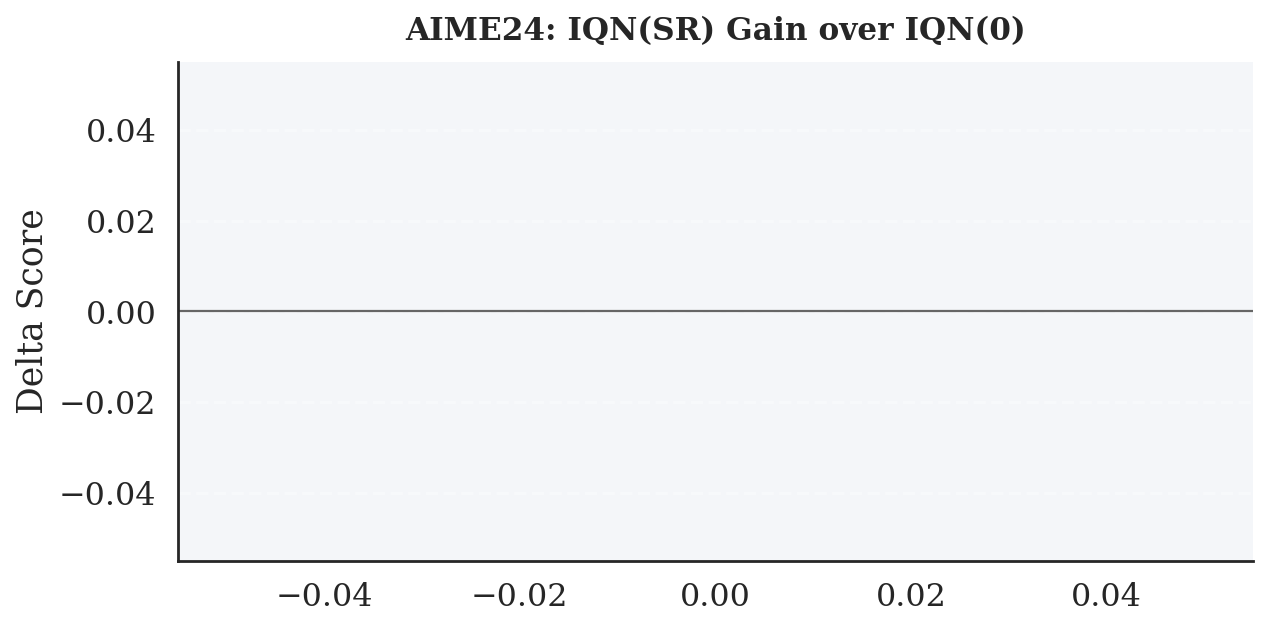

In [23]:
# ====== 风格 D：增益柱 (IQN(SR) - IQN(0)) ======
fig, ax = plt.subplots(figsize=(8.2, 4.2), dpi=160)

gain_rows = []
for g in group_order:
    sub = df[df['Group'] == g].set_index('Method')
    if 'IQN(0)' in sub.index and 'IQN(SR)' in sub.index:
        gain = sub.loc['IQN(SR)', 'Score'] - sub.loc['IQN(0)', 'Score']
        gain_rows.append((g, gain))

glabels = [g for g, _ in gain_rows]
gvals = [v for _, v in gain_rows]

bars = ax.bar(glabels, gvals, color=palette['IQN(SR)'], edgecolor='black', linewidth=0.5)
ax.axhline(0, color='#666', lw=1)

# 数值标注（更大字号 + 白底）
for b, v in zip(bars, gvals):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + (0.02 if v >= 0 else -0.04),
        '{:+.3f}'.format(v),
        ha='center',
        va='bottom' if v >= 0 else 'top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
    )

ax.set_title('AIME24: IQN(SR) Gain over IQN(0)', fontsize=14, pad=10, weight='bold')
ax.set_ylabel('Delta Score')
ax.grid(axis='y', linestyle='--', alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_47172/3566779573.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  sub['Group'] = pd.Categorical(sub['Group'], categories=group_order, ordered=True)
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_47172/3566779573.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  sub['Group'] = pd.Categorical(sub['Group'], categories=group_order, ordered=True)
/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_47172/3566779573.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  sub['Group'] = pd.Categorical(sub['Group'], categories=g

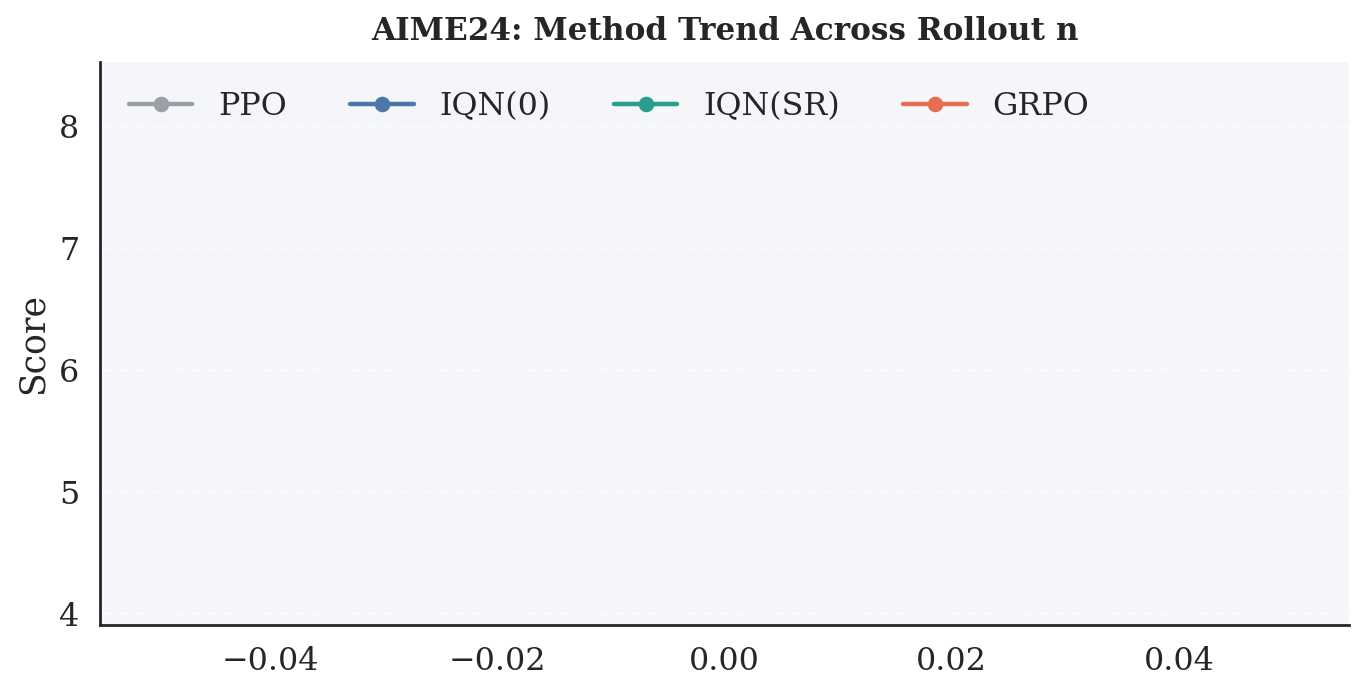

In [24]:
# ====== 风格 E：方法随 Rollout n 的趋势 (Slope/Line) ======
fig, ax = plt.subplots(figsize=(8.8, 4.6), dpi=160)

# 只画各 method 的趋势线（存在的点才连）
for method in method_order:
    sub = df[df['Method'] == method].copy()
    if sub.empty:
        continue
    sub['Group'] = pd.Categorical(sub['Group'], categories=group_order, ordered=True)
    sub = sub.sort_values('Group')
    ax.plot(sub['Group'], sub['Score'], marker='o', lw=2, color=palette.get(method, '#666'), label=method, zorder=2)
    for x, y in zip(sub['Group'], sub['Score']):
        ax.text(
            x, y + 0.06, '{:.2f}'.format(y),
            ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3,
        )

ax.set_title('AIME24: Method Trend Across Rollout n', fontsize=14, pad=10, weight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(ncol=4, frameon=False, loc='upper left')
ymin = df['Score'].min() - 0.4
ymax = df['Score'].max() + 0.4
ax.set_ylim(ymin, ymax)
sns.despine()
plt.tight_layout()
plt.show()


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


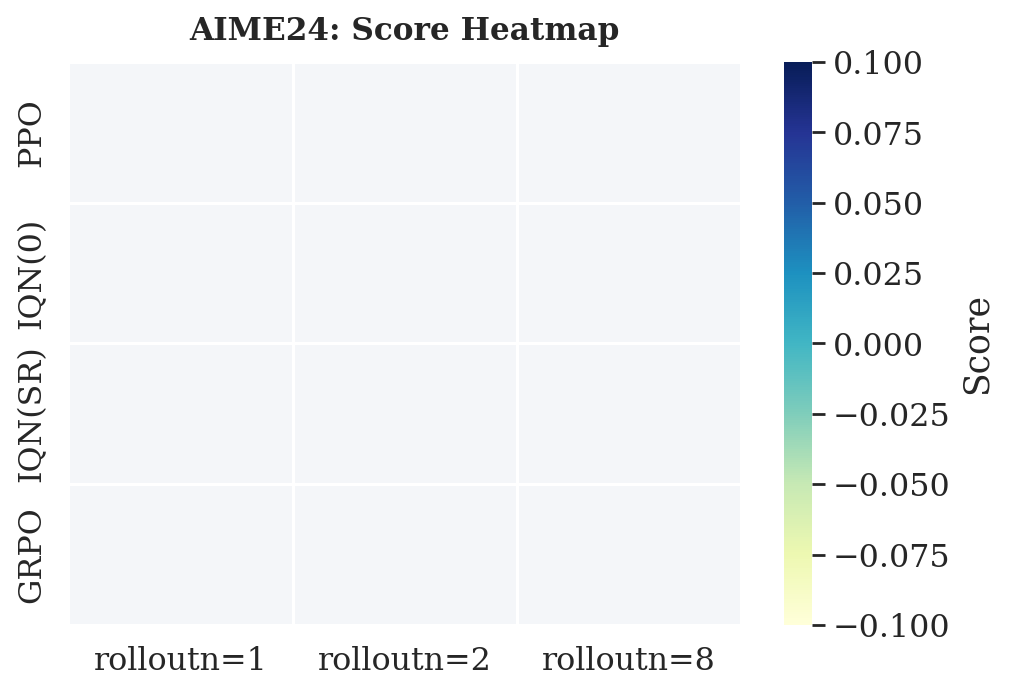

In [25]:
# ====== 风格 F：热力图 (Method x Rollout n) ======
fig, ax = plt.subplots(figsize=(6.6, 4.6), dpi=160)

pivot = df.pivot(index='Method', columns='Group', values='Score')
pivot = pivot.reindex(index=method_order, columns=group_order)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Score'},
    annot_kws={'fontsize': 10, 'bbox': dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7)},
    ax=ax,
)

ax.set_title('AIME24: Score Heatmap', fontsize=14, pad=10, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


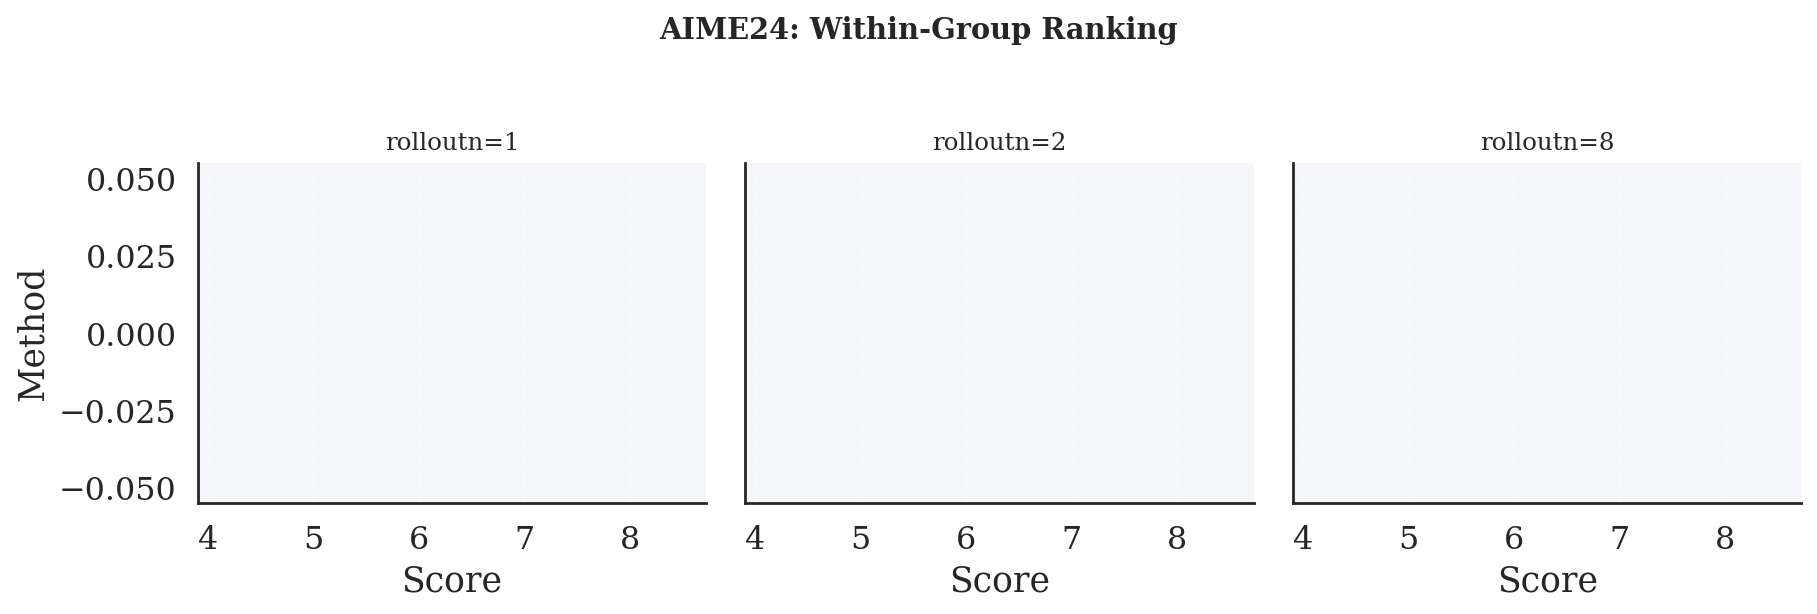

In [26]:
# ====== 风格 G：每组内排序 (Rank Bars) ======
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), dpi=160, sharey=True)

for ax, g in zip(axes, group_order):
    sub = df[df['Group'] == g].sort_values('Score', ascending=True)
    colors = [palette.get(m, '#666') for m in sub['Method']]
    bars = ax.barh(sub['Method'], sub['Score'], color=colors, edgecolor='black', linewidth=0.4)
    for b, v in zip(bars, sub['Score']):
        ax.text(
            v + 0.04, b.get_y() + b.get_height() / 2,
            '{:.3f}'.format(v),
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
        )
    ax.set_title(g, fontsize=11)
    ax.set_xlabel('Score')

axes[0].set_ylabel('Method')
ymin = df['Score'].min() - 0.4
ymax = df['Score'].max() + 0.6
for ax in axes:
    ax.set_xlim(ymin, ymax)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('AIME24: Within-Group Ranking', fontsize=13, y=1.02, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()
